In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from dowhy import CausalModel
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize



In [2]:
def load_and_preprocess(path):
    df = pd.read_csv(path)
    print("Original rows:", len(df))

    df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
    print("After removing obfuscated:", len(df))

    df["verdict"] = df["verdict"].astype(int)
    df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
    df["lib_category"] = df["code_location"].apply(
        lambda x: x if x != "developer_written" else "source"
    )

    scaler = RobustScaler()
    df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

    print("\nVerdict value counts:")
    print(df["verdict"].value_counts())
    
    return df


In [3]:
def compute_tp_stats_and_power(df):
    alpha=0.05
    power_target=0.8

    tp_developer = df.loc[df["is_third_party"] == 0, "verdict"].mean()
    tp_third = df.loc[df["is_third_party"] == 1, "verdict"].mean()
    n_dev = (df["is_third_party"] == 0).sum()
    n_third = (df["is_third_party"] == 1).sum()

    print("Alerts from Developer written codes, TP rate:", tp_developer, "|| n =", n_dev)
    print("Alerts from Third-party library codes, TP rate:", tp_third, "|| n =", n_third)
    print("Observed difference:", tp_third - tp_developer)

    effect_size = proportion_effectsize(tp_third, tp_developer)
    ratio = n_third / n_dev

    power_analysis = NormalIndPower()

    power = power_analysis.power(
        effect_size=effect_size,
        nobs1=n_dev,
        alpha=alpha,
        ratio=ratio,
        alternative='two-sided'
    )
    print("Post-hoc power current N:", power)

    n_dev_required = power_analysis.solve_power(
        effect_size=effect_size,
        power=power_target,
        alpha=alpha,
        ratio=ratio,
        alternative='two-sided'
    )
    n_third_required = n_dev_required * ratio

    print("Required # of alerts from dev-written code for 80% power:", n_dev_required)
    print("Required # of alerts from third-party code for 80% power:", n_third_required)

In [4]:
def downsample_to_balanced(df):
    majority = df[df["is_third_party"] == 1]
    minority = df[df["is_third_party"] == 0]
    n_min = len(minority)

    down_sample = majority.sample(n=n_min, replace=False, random_state=42)

    df_bal = pd.concat([down_sample, minority], axis=0)
    df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

    print("\nBalanced is_third_party counts:")
    print(df_bal["is_third_party"].value_counts())

    return df_bal

In [5]:
def plot_power_analysis_figures(df,status):
    n_boot=2000
    alpha=0.05

    tp_dev = df.loc[df["is_third_party"] == 0, "verdict"].mean()
    tp_third = df.loc[df["is_third_party"] == 1, "verdict"].mean()
    diff_obs = tp_third - tp_dev

    n_dev = (df["is_third_party"] == 0).sum()
    n_third = (df["is_third_party"] == 1).sum()
    ratio = n_third / n_dev

    print("Group size ratio (n_third-party / n_dev):", ratio)

    diffs = []

    for _ in range(n_boot):
        boot = df.sample(frac=1, replace=True)
        p_dev_b = boot.loc[boot["is_third_party"] == 0, "verdict"].mean()
        p_third_b = boot.loc[boot["is_third_party"] == 1, "verdict"].mean()
        diffs.append(p_third_b - p_dev_b)

    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)

    print("\nBootstrap effect distribution")
    print("Bootstrap mean diff:", mean_diff)
    print("Bootstrap 95% CI:", ci_lower, ci_upper)

    plt.figure(figsize=(8, 5))
    plt.hist(diffs, bins=30, density=True, alpha=0.7)

    plt.axvline(mean_diff, color="black", linestyle="-", linewidth=2, label="Bootstrap mean")
    plt.axvline(diff_obs, color="red", linestyle="--", linewidth=2, label="Observed diff")
    plt.axvline(ci_lower, color="gray", linestyle=":", linewidth=1, label="95% CI bounds")
    plt.axvline(ci_upper, color="gray", linestyle=":", linewidth=1)

    plt.xlabel("Difference in TP rate (third-party − dev)")
    plt.ylabel("Density")
    plt.title(f"Bootstrap distribution of TP-rate difference\n{status} Sample")
    plt.legend()
    plt.tight_layout()
    plt.show()


    effect_size = proportion_effectsize(tp_third, tp_dev)
    print("\nCohen's h (proportion effect size):", effect_size)

    power_analysis = NormalIndPower()



    n_dev_grid = np.arange(20, 601, 20)

    powers = [
        power_analysis.power(
            effect_size=effect_size,
            nobs1=n,
            alpha=alpha,
            ratio=ratio,
            alternative='two-sided'
        )
        for n in n_dev_grid
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(n_dev_grid, powers, marker="o")

    plt.axhline(0.8, color="gray", linestyle="--", label="80% power")
    plt.axvline(n_dev, color="red", linestyle=":",
                label=f"Actual n_dev = {n_dev} (n_third-party ≈ {int(n_dev * ratio)})")

    plt.xlabel("Developer-written alerts (n_dev)\n(ratio n_third -party/ n_dev fixed)")
    plt.ylabel("Power")
    plt.title(f"Power curve for TP-rate difference\n{status}  Sample, α={alpha}")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


Original rows: 15287
After removing obfuscated: 15268

Verdict value counts:
verdict
0    7911
1    7357
Name: count, dtype: int64

------ Power analysis on full (unbalanced) data ------
Alerts from Developer written codes, TP rate: 0.510188679245283 || n = 1325
Alerts from Third-party library codes, TP rate: 0.4791651724879868 || n = 13943
Observed difference: -0.031023506757296204
Post-hoc power current N: 0.5788192280532183
Required # of alerts from dev-written code for 80% power: 2231.5267701883704
Required # of alerts from third-party code for 80% power: 23482.398306970907
Group size ratio (n_third-party / n_dev): 10.52301886792453

Bootstrap effect distribution
Bootstrap mean diff: -0.03105740119810519
Bootstrap 95% CI: -0.05758880457706701 -0.004219253504676407


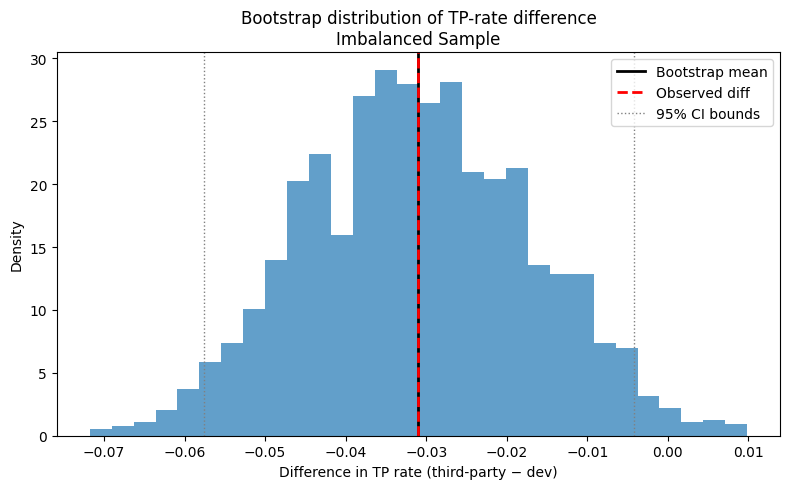


Cohen's h (proportion effect size): -0.06206049236969169


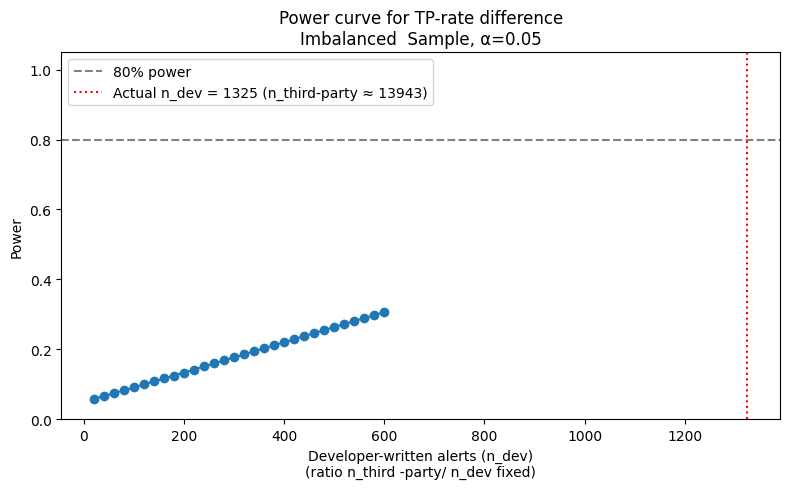


Balanced is_third_party counts:
is_third_party
0    1325
1    1325
Name: count, dtype: int64

------ Power analysis on balanced data ------
Alerts from Developer written codes, TP rate: 0.510188679245283 || n = 1325
Alerts from Third-party library codes, TP rate: 0.45660377358490567 || n = 1325
Observed difference: -0.053584905660377324
Post-hoc power current N: 0.7885332968012208
Required # of alerts from dev-written code for 80% power: 1363.9377343200144
Required # of alerts from third-party code for 80% power: 1363.9377343200144
Group size ratio (n_third-party / n_dev): 1.0

Bootstrap effect distribution
Bootstrap mean diff: -0.05286565931362428
Bootstrap 95% CI: -0.09021026925805398 -0.014179593984445345


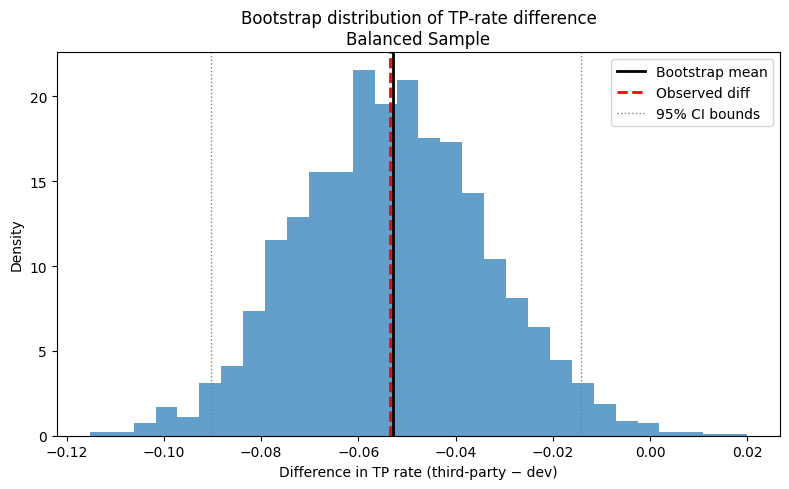


Cohen's h (proportion effect size): -0.10728055977518669


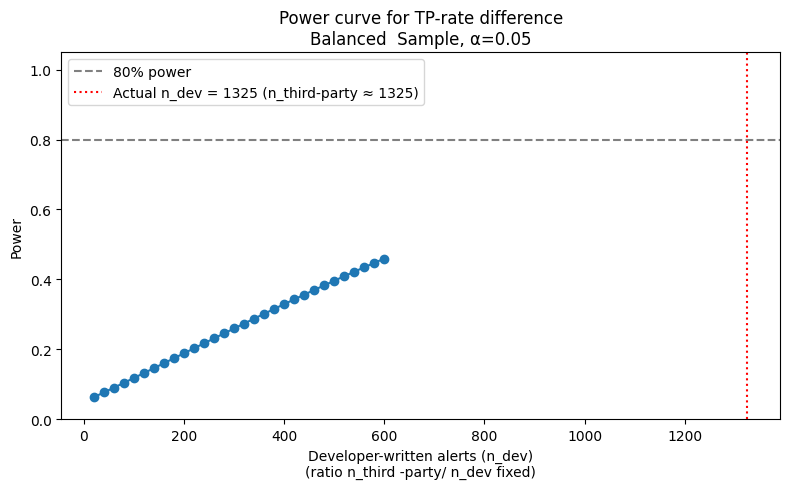

In [6]:
df = load_and_preprocess("alerts_with_category_and_apk_size_updated_cryptoguard.csv")
print("\n------ Power analysis on full (unbalanced) data ------")

compute_tp_stats_and_power(df)
plot_power_analysis_figures(df,"Imbalanced")

df = downsample_to_balanced(df)
print("\n------ Power analysis on balanced data ------")

compute_tp_stats_and_power(df)
plot_power_analysis_figures(df,"Balanced")